In [2]:
# Cell 0: Install required packages
# The '!' tells Jupyter to run a terminal command
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

In [3]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Set plotting style for professional visuals
plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [4]:
# Cell 2: Metabolic Model (The "Brand" Feature)
class MetabolicModel:
    def __init__(self, insulin_brand="Humalog"):
        # Tau (peak time) in minutes
        self.brands = {
            "Fiasp": 45,       # Ultra-fast
            "Humalog": 60,     # Standard Rapid
            "Novolog": 60,
            "Actrapid": 120    # Short-acting (Slower)
        }
        self.tau = self.brands.get(insulin_brand, 60)
        print(f"Model initialized for {insulin_brand} (Peak: ~{self.tau} min)")

    def calculate_iob(self, insulin_series, time_interval=5):
        """
        Converts discrete insulin injections into a continuous 'Active Insulin' curve.
        """
        # Duration of action is roughly 3-4x the peak time
        duration_steps = int((3.5 * self.tau) / time_interval)

        # Create the decay curve (Kernel) for 1 unit of insulin
        t = np.linspace(0, 3.5 * self.tau, duration_steps)
        # Mathematical approximation of insulin absorption: t * exp(-t/tau)
        kernel = (t / self.tau) * np.exp(-t / self.tau)

        # Normalize kernel so total area equals 1 unit (conservation of mass)
        if np.sum(kernel) > 0:
            kernel = kernel / np.sum(kernel)

        # Convolve the insulin series with the decay kernel
        # This smears the discrete doses forward in time
        insulin_filled = insulin_series.fillna(0).values
        iob = np.convolve(insulin_filled, kernel, mode='full')

        return iob[:len(insulin_series)]

print("Metabolic Model Class Defined.")

Metabolic Model Class Defined.


In [5]:
# Cell 3: Load and Clean Data
# REPLACE 'P16.csv' with your specific file path if different
FILE_PATH = 'P16.csv'

def load_data(filepath):
    print(f"Loading {filepath}...")
    df = pd.read_csv(filepath)

    # 1. Time Processing
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 2. Convert mmol/L to mg/dL (CRITICAL FIX!)
    # Data is in mmol/L (European standard), need to convert to mg/dL
    # Check if values are in mmol/L range (typically 3-15) vs mg/dL (typically 70-300)
    if df['bg'].median() < 30:  # Definitely mmol/L
        print("⚠️  Data detected in mmol/L. Converting to mg/dL...")
        df['bg'] = df['bg'] * 18.0  # Conversion factor

    # 3. Glucose Interpolation (Linear fill for small sensor gaps)
    df['bg'] = df['bg'].interpolate(method='linear', limit=4)
    # Drop remaining NaNs (large gaps where we shouldn't guess)
    df = df.dropna(subset=['bg'])

    # 3. Fill NaN for events that only appear when they happen
    df['insulin'] = df['insulin'].fillna(0)
    df['carbs'] = df['carbs'].fillna(0)
    df['hr'] = df['hr'].fillna(method='ffill').fillna(65) # Default HR
    df['steps'] = df['steps'].fillna(0)

    # 4. Feature Engineering: IOB (Insulin on Board)
    # TRY CHANGING THIS TO 'Fiasp' OR 'Actrapid' TO SEE THE DIFFERENCE
    metabolic_model = MetabolicModel(insulin_brand="Humalog")
    df['IOB'] = metabolic_model.calculate_iob(df['insulin'])

    # 5. Feature Engineering: Time Signals (Cyclical encoding)
    day_seconds = 24 * 60 * 60
    seconds = df['timestamp'].map(pd.Timestamp.timestamp)
    df['Day_Sin'] = np.sin(seconds * (2 * np.pi / day_seconds))
    df['Day_Cos'] = np.cos(seconds * (2 * np.pi / day_seconds))

    return df

df = load_data(FILE_PATH)
print(f"Data Loaded. Shape: {df.shape}")
print(df[['timestamp', 'bg', 'insulin', 'IOB']].head())

Loading P16.csv...
⚠️  Data detected in mmol/L. Converting to mg/dL...
Model initialized for Humalog (Peak: ~60 min)


/tmp/ipython-input-3624158224.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['hr'] = df['hr'].fillna(method='ffill').fillna(65) # Default HR


Data Loaded. Shape: (159431, 13)
                  timestamp     bg  insulin  IOB
0 2023-06-05 02:11:00+00:00  131.4      0.0  0.0
1 2023-06-05 02:16:00+00:00  129.6      0.0  0.0
2 2023-06-05 02:21:00+00:00  126.0      0.0  0.0
3 2023-06-05 02:26:00+00:00  126.0      0.0  0.0
4 2023-06-05 02:31:00+00:00  124.2      0.0  0.0


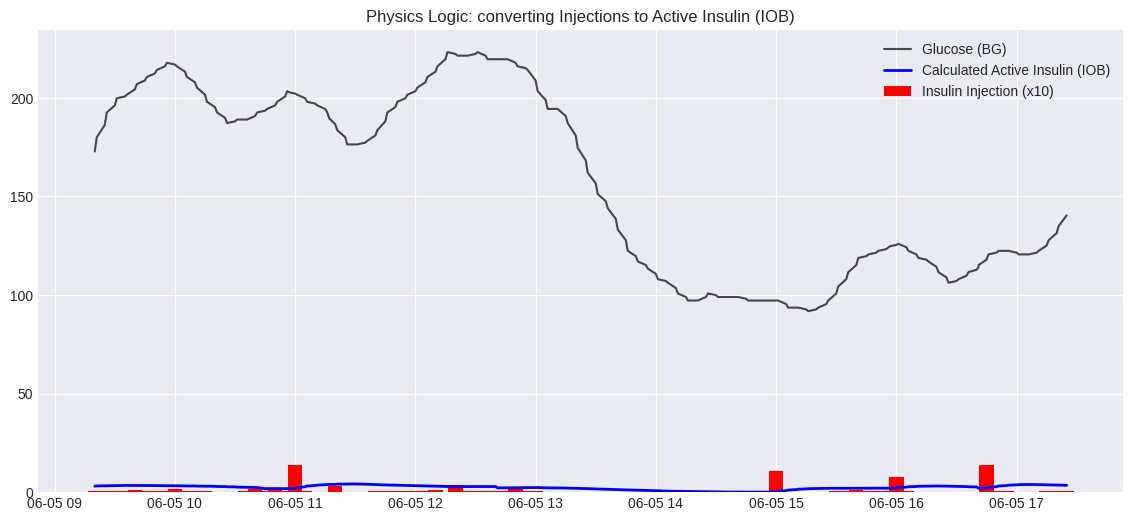

In [6]:
# Cell 4: Visualizing Feature Engineering
plt.figure(figsize=(14, 6))

# Plot normalized values to fit on one chart
plt.plot(df['timestamp'][100:300], df['bg'][100:300], label='Glucose (BG)', color='black', alpha=0.7)
plt.bar(df['timestamp'][100:300], df['insulin'][100:300]*10, label='Insulin Injection (x10)', color='red', width=0.005)
plt.plot(df['timestamp'][100:300], df['IOB'][100:300]*50, label='Calculated Active Insulin (IOB)', color='blue', linewidth=2)

plt.title("Physics Logic: converting Injections to Active Insulin (IOB)")
plt.legend()
plt.show()

In [7]:
# Cell 5: Create Sliding Windows for LSTM
def create_dataset(df, look_back=24, prediction_horizon=6):
    """
    look_back: 24 steps = 2 hours of history (assuming 5 min intervals)
    prediction_horizon: 6 steps = 30 mins into the future
    """
    features = ['bg', 'IOB', 'carbs', 'hr', 'steps', 'Day_Sin', 'Day_Cos']
    data = df[features].values

    # Scale Data (LSTMs need inputs between 0 and 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(data_scaled) - look_back - prediction_horizon):
        X.append(data_scaled[i : i + look_back])
        # We predict only the BG column (index 0)
        y.append(data_scaled[i + look_back + prediction_horizon, 0])

    return np.array(X), np.array(y), scaler

# Parameters
LOOK_BACK = 36      # 3 Hours History
HORIZON = 36        # Predict 1 Hour Future
SPLIT = 0.8         # 80% Train, 20% Test

X, y, scaler = create_dataset(df, LOOK_BACK, HORIZON)

# Split Train/Test
split_idx = int(len(X) * SPLIT)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (127487, 36, 7)
Testing Shape: (31872, 36, 7)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 0.0144 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 2/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0100 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.0095 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.0092 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 5/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0090 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 6/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0088 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 7/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0087 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 8/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 0.0086 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 9/50
3586/3586 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0084 - val_loss: 0.0097 - learn

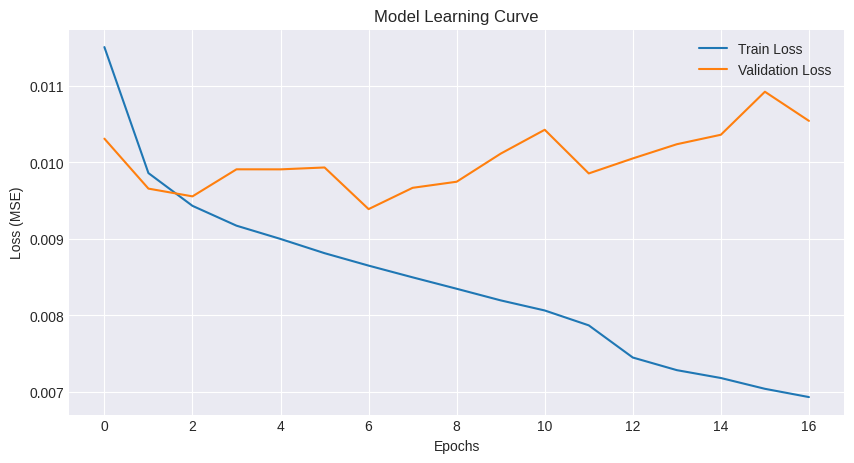

In [8]:
# Cell 6: Build and Train LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Linear output for regression
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Callbacks for better training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,            # Increased from 20
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot Training History
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

996/996 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Validation MAE (Subject 16): 24.29 mg/dL


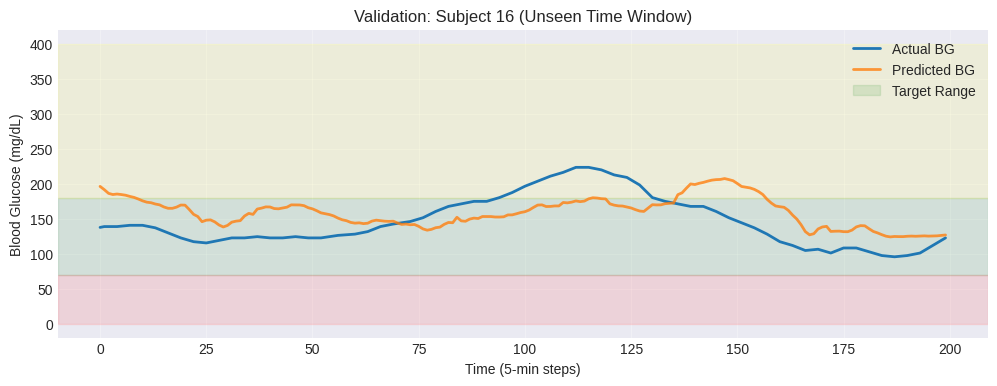

In [9]:
# Cell 7: Validation on Subject 16 (unseen time segment)

from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- 1. Time-based split (NO SHUFFLING) ---
split_idx = int(0.8 * len(X))  # last 20% is validation

X_val = X[split_idx:]
y_val = y[split_idx:]

# --- 2. Predict ---
y_val_pred = model.predict(X_val).flatten()

# --- 3. Inverse transform to get real mg/dL values ---
# Create dummy arrays for inverse transform (scaler needs all features)
dummy_y_val = np.zeros((len(y_val), scaler.n_features_in_))
dummy_y_val[:, 0] = y_val  # BG is first feature
actual_bg_val = scaler.inverse_transform(dummy_y_val)[:, 0]

dummy_y_pred = np.zeros((len(y_val_pred), scaler.n_features_in_))
dummy_y_pred[:, 0] = y_val_pred
predicted_bg_val = scaler.inverse_transform(dummy_y_pred)[:, 0]

# --- 4. Metric (now in real mg/dL) ---
mae = mean_absolute_error(actual_bg_val, predicted_bg_val)
print(f"Validation MAE (Subject 16): {mae:.2f} mg/dL")

# --- 5. Plot (now in real mg/dL) ---
plt.figure(figsize=(12,4))
plt.plot(actual_bg_val[:200], label="Actual BG", linewidth=2)
plt.plot(predicted_bg_val[:200], label="Predicted BG", linewidth=2, alpha=0.8)
plt.axhspan(70, 180, alpha=0.1, color='green', label='Target Range')
plt.axhspan(0, 70, alpha=0.1, color='red')
plt.axhspan(180, 400, alpha=0.1, color='yellow')
plt.legend()
plt.title("Validation: Subject 16 (Unseen Time Window)")
plt.xlabel("Time (5-min steps)")
plt.ylabel("Blood Glucose (mg/dL)")
plt.grid(True, alpha=0.3)
plt.show()


Loading P17.csv...
⚠️  Data detected in mmol/L. Converting to mg/dL...
Model initialized for Humalog (Peak: ~60 min)


/tmp/ipython-input-3624158224.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['hr'] = df['hr'].fillna(method='ffill').fillna(65) # Default HR


Data for Subject 17 Loaded. Shape: (104705, 13)
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Test MAE (Subject 17): 39.39


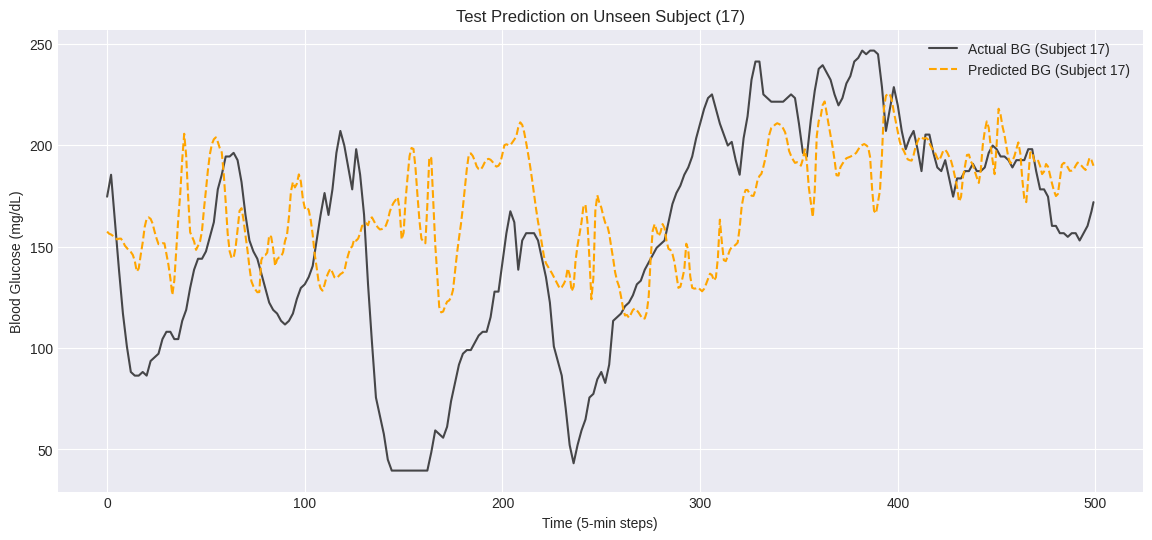

In [10]:
# Cell 8: Testing on Subject 17 (unseen subject)

# --- 1. Load and Preprocess Subject 17 using the same function as Subject 16 ---
FILE_PATH_17 = 'P17.csv'
df17 = load_data(FILE_PATH_17)
print(f"Data for Subject 17 Loaded. Shape: {df17.shape}")

# --- 2. Infer feature count and look_back from training data ---
# X shape = (samples, look_back, num_features)
look_back = X.shape[1]

# --- 3. Extract and Scale Features for Subject 17 ---
# Ensure the features match those used during training
features = ['bg', 'IOB', 'carbs', 'hr', 'steps', 'Day_Sin', 'Day_Cos']
features_17 = df17[features].values

# Scale using the SAME scaler fitted on Subject 16 data
features_17_scaled = scaler.transform(features_17)

# --- 4. Build sequences for Subject 17 ---
X_test_17, y_test_17 = [], []

for i in range(len(features_17_scaled) - look_back - HORIZON):
    X_test_17.append(features_17_scaled[i : i + look_back])
    # We predict only the BG column (index 0) of the scaled data
    y_test_17.append(features_17_scaled[i + look_back + HORIZON, 0])

X_test_17 = np.array(X_test_17)
y_test_17 = np.array(y_test_17)

# --- 5. Predict ---
if len(X_test_17) == 0:
    print("❌ No test sequences available for Subject 17 after preprocessing and sequence creation.")
else:
    y_test_pred_17 = model.predict(X_test_17).flatten()

    # --- 6. Inverse transform the scaled predictions and actual values to original BG units ---
    # Create dummy arrays to inverse transform only the BG column
    dummy_y_test_17 = np.zeros((len(y_test_17), scaler.n_features_in_))
    dummy_y_test_17[:, 0] = y_test_17
    actual_bg_17 = scaler.inverse_transform(dummy_y_test_17)[:, 0]

    dummy_y_pred_17 = np.zeros((len(y_test_pred_17), scaler.n_features_in_))
    dummy_y_pred_17[:, 0] = y_test_pred_17
    predicted_bg_17 = scaler.inverse_transform(dummy_y_pred_17)[:, 0]

    # --- 7. Metric ---
    mae_17 = mean_absolute_error(actual_bg_17, predicted_bg_17)
    print(f"Test MAE (Subject 17): {mae_17:.2f}")

    # --- 8. Plot ---
    N_plot = min(500, len(actual_bg_17)) # Plot up to 500 points or less if data is short

    plt.figure(figsize=(14,6))
    plt.plot(actual_bg_17[:N_plot], label="Actual BG (Subject 17)", color='black', alpha=0.7)
    plt.plot(predicted_bg_17[:N_plot], label="Predicted BG (Subject 17)", color='orange', linestyle='--')
    plt.legend()
    plt.title("Test Prediction on Unseen Subject (17)")
    plt.xlabel("Time (5-min steps)")
    plt.ylabel("Blood Glucose (mg/dL)")
    plt.show()

In [11]:
# Cell X: Single Prediction Example for P03

# Re-load P03 data (since it was just loaded as P17 in the previous Cell 8 run)
FILE_PATH_P03 = 'P03.csv'
df_p03 = load_data(FILE_PATH_P03)
print(f"Data for P03 Loaded. Shape: {df_p03.shape}")

# Ensure look_back and HORIZON match the model's training configuration
look_back = LOOK_BACK # 36 steps = 3 hours
prediction_horizon = HORIZON # 36 steps = 3 hours
num_features = X.shape[2] # 7 features

# Choose a random index from P03 data for prediction
# Ensure there's enough history before and enough space for prediction_horizon after
max_index = len(df_p03) - look_back - prediction_horizon - 1
if max_index < 0:
    print("❌ Not enough data in P03 to create a prediction sequence with the current look_back and horizon.")
else:
    random_idx = np.random.randint(0, max_index)
    print(f"Selected timestamp index for prediction: {random_idx}")
    print(f"Corresponding timestamp: {df_p03.iloc[random_idx + look_back]['timestamp']}")

    # 1. Extract the 'look_back' window of features for input
    # The input window ends right before the prediction_horizon starts
    raw_window = df_p03[features].iloc[random_idx : random_idx + look_back].values

    # 2. Scale the input window using the SAME scaler fitted on P16 data
    scaled_window = scaler.transform(raw_window)

    # 3. Reshape for LSTM input (add batch dimension)
    lstm_input = scaled_window.reshape(1, look_back, num_features)

    # 4. Make prediction with the trained model
    pred_scaled = model.predict(lstm_input, verbose=0).flatten()[0]

    # 5. Inverse transform the scaled prediction to original BG units
    dummy_row = np.zeros((1, scaler.n_features_in_))
    dummy_row[0, 0] = pred_scaled
    final_prediction = scaler.inverse_transform(dummy_row)[0, 0]

    # 6. Get the actual BG value for comparison (from the prediction_horizon)
    actual_bg_time_idx = random_idx + look_back + prediction_horizon
    actual_bg_scaled = scaler.transform(df_p03[features].iloc[actual_bg_time_idx:actual_bg_time_idx+1].values)[:, 0]
    dummy_actual_row = np.zeros((1, scaler.n_features_in_))
    dummy_actual_row[0,0] = actual_bg_scaled
    actual_bg_value = scaler.inverse_transform(dummy_actual_row)[0, 0]

    print(f"Predicted BG for {df_p03.iloc[random_idx + look_back + prediction_horizon]['timestamp']} (3 hours after window end): {final_prediction:.2f} mg/dL")
    print(f"Actual BG at that time: {actual_bg_value:.2f} mg/dL")

Loading P03.csv...
⚠️  Data detected in mmol/L. Converting to mg/dL...
Model initialized for Humalog (Peak: ~60 min)
Data for P03 Loaded. Shape: (81798, 13)
Selected timestamp index for prediction: 64116
Corresponding timestamp: 2023-08-16 13:20:00+00:00


/tmp/ipython-input-3624158224.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['hr'] = df['hr'].fillna(method='ffill').fillna(65) # Default HR


Predicted BG for 2023-08-16 14:20:00+00:00 (3 hours after window end): 103.86 mg/dL
Actual BG at that time: 109.80 mg/dL


/tmp/ipython-input-623608816.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy_actual_row[0,0] = actual_bg_scaled


In [12]:
# SCENARIO 1: Post-Meal Prediction (3-4 hours forward)
# User has already eaten and taken insulin, wants to know future glucose levels

def predict_post_meal_glucose(current_bg_readings, insulin_doses, carb_intakes,
                               hr_data, steps_data, timestamps,
                               hours_forward=3,
                               use_dampening=True,
                               use_smoothing=True,
                               constrain_rate=True):
    """
    Predict glucose levels for the next N hours given recent history

    Parameters:
    -----------
    current_bg_readings : list of float
        Recent BG readings (enough for look_back period, e.g., last 3 hours)
    insulin_doses : list of float
        Recent insulin doses corresponding to the timestamps
    carb_intakes : list of float
        Recent carb intake corresponding to the timestamps
    hr_data : list of float
        Heart rate data
    steps_data : list of float
        Steps data
    timestamps : list of datetime
        Timestamps for the readings (must match look_back period)
    hours_forward : int
        How many hours to predict forward (default 3)
    use_dampening : bool
        Option A: Apply dampening to early predictions to reduce initial spikes (default False)
    use_smoothing : bool
        Option B: Apply moving average smoothing to reduce spikes (default False)
    constrain_rate : bool
        Option C: Constrain rate of change to biologically realistic values (default False)

    Returns:
    --------
    predictions : list of tuples (timestamp, predicted_bg)
    """

    # Calculate IOB from insulin history
    metabolic_model = MetabolicModel(insulin_brand="Humalog")
    insulin_series = pd.Series(insulin_doses)
    iob_values = metabolic_model.calculate_iob(insulin_series)

    # Calculate time features
    day_seconds = 24 * 60 * 60
    seconds = [pd.Timestamp(t).timestamp() for t in timestamps]
    day_sin = [np.sin(s * (2 * np.pi / day_seconds)) for s in seconds]
    day_cos = [np.cos(s * (2 * np.pi / day_seconds)) for s in seconds]

    # Construct feature matrix
    features_array = np.column_stack([
        current_bg_readings,
        iob_values,
        carb_intakes,
        hr_data,
        steps_data,
        day_sin,
        day_cos
    ])

    # Scale the features
    features_scaled = scaler.transform(features_array)

    # We need exactly look_back steps
    if len(features_scaled) < LOOK_BACK:
        raise ValueError(f"Need at least {LOOK_BACK} data points ({LOOK_BACK * 5} minutes)")

    # Use the most recent look_back steps
    input_window = features_scaled[-LOOK_BACK:]
    lstm_input = input_window.reshape(1, LOOK_BACK, -1)

    # Multi-step prediction
    predictions = []
    raw_predictions = []  # Store for smoothing
    num_steps = (hours_forward * 60) // 5  # Convert hours to 5-min steps

    last_timestamp = pd.Timestamp(timestamps[-1])
    last_real_bg = current_bg_readings[-1]  # Store last real BG for dampening

    # For multi-step prediction, we'll use an iterative approach
    current_window = input_window.copy()

    for step in range(num_steps):
        # Predict next step
        pred_scaled = model.predict(current_window.reshape(1, LOOK_BACK, -1), verbose=0).item()

        # Inverse transform to get actual BG
        dummy_pred = np.zeros((1, scaler.n_features_in_))
        dummy_pred[0, 0] = pred_scaled
        pred_bg = scaler.inverse_transform(dummy_pred)[0, 0]

        # OPTION A: DAMPENING - Reduce trust in early predictions
        if use_dampening and step < 6:  # First 30 minutes (6 steps)
            trust_factor = 0.3 + (step / 6) * 0.7  # Gradually increase from 30% to 100%
            pred_bg = last_real_bg * (1 - trust_factor) + pred_bg * trust_factor
            # print(f"   Step {step}: Dampening applied, trust={trust_factor:.2f}")  # Debug

        # OPTION C: RATE CONSTRAINT - Limit biological rate of change
        if constrain_rate and len(raw_predictions) > 0:
            last_pred_bg = raw_predictions[-1]
            max_change = 3.0  # mg/dL per 5 minutes (biological limit)
            change = pred_bg - last_pred_bg
            if abs(change) > max_change:
                pred_bg = last_pred_bg + max_change * np.sign(change)
                # print(f"   Step {step}: Rate constraint applied, limited to {max_change} mg/dL")  # Debug

        # Store raw prediction before smoothing
        raw_predictions.append(pred_bg)

        # Calculate timestamp for this prediction
        pred_timestamp = last_timestamp + pd.Timedelta(minutes=(step + 1) * 5)
        predictions.append((pred_timestamp, pred_bg))

        # For iterative prediction, we need to construct the next input
        # This assumes no new insulin/carbs (user is asking about existing state)
        # Create a new feature vector with predicted BG
        new_seconds = pd.Timestamp(pred_timestamp).timestamp()
        new_day_sin = np.sin(new_seconds * (2 * np.pi / day_seconds))
        new_day_cos = np.cos(new_seconds * (2 * np.pi / day_seconds))

        # Decay IOB (simple linear decay for this step)
        last_iob = current_window[-1, 1] * 0.95  # Approximate decay

        new_features = np.array([[pred_scaled, last_iob, 0, hr_data[-1], 0, new_day_sin, new_day_cos]])

        # Slide the window forward
        current_window = np.vstack([current_window[1:], new_features])

    # OPTION B: SMOOTHING - Apply moving average to reduce spikes
    if use_smoothing:
        smoothed_predictions = []
        window_size = 5  # 5-point moving average (25 minutes)
        for i in range(len(predictions)):
            # Get window indices (centered around current point)
            start_idx = max(0, i - window_size // 2)
            end_idx = min(len(raw_predictions), i + window_size // 2 + 1)
            window_values = raw_predictions[start_idx:end_idx]
            smoothed_bg = np.mean(window_values)
            smoothed_predictions.append((predictions[i][0], smoothed_bg))
        predictions = smoothed_predictions

    return predictions

print("✅ Post-meal prediction function defined")

✅ Post-meal prediction function defined


📱 User Scenario: Just finished dinner
Current BG: 93.6 mg/dL
Recent insulin: 9.39 units in last 3 hours
Recent carbs: 60.0g in last 3 hours

🔮 Predicting glucose for next 3 hours...
Model initialized for Humalog (Peak: ~60 min)

📊 Prediction Results:
In 1 hour: 130.4 mg/dL
In 2 hours: 139.7 mg/dL
In 3 hours: 159.3 mg/dL


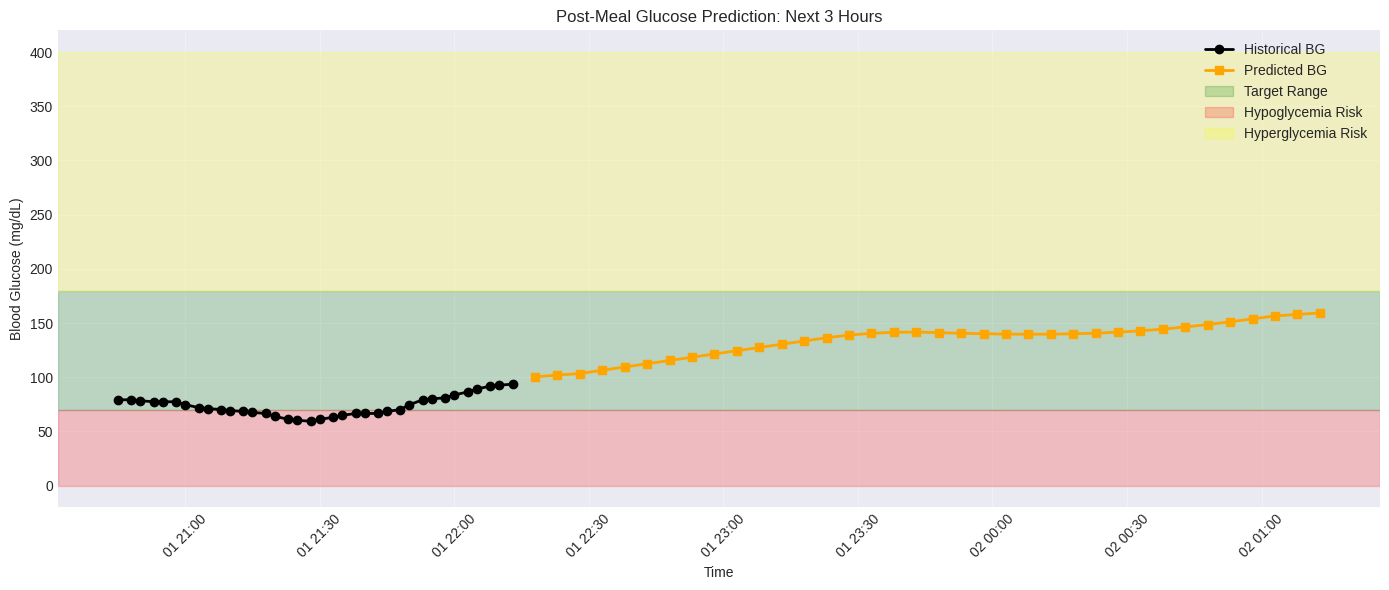


✅ Glucose levels predicted to stay in target range
   Safe for sleep or physical activity


In [13]:
# SCENARIO 1 EXAMPLE: User just ate and took insulin, wants to predict before sleep

# Example: User's recent data (last 3 hours = 36 readings at 5-min intervals)
# You would replace this with actual CGM readings from the device

# Let's simulate a realistic scenario using data from the dataset
sample_person = df_p03  # You can change to df, df17, etc.

# Pick a recent window (e.g., person just had dinner at 18:00)
start_idx = 500  # Adjust this to pick different times
end_idx = start_idx + LOOK_BACK

# Extract real history
recent_history = sample_person.iloc[start_idx:end_idx]

# Current user inputs
user_bg = recent_history['bg'].tolist()
user_insulin = recent_history['insulin'].tolist()
user_carbs = recent_history['carbs'].tolist()
user_hr = recent_history['hr'].tolist()
user_steps = recent_history['steps'].tolist()
user_timestamps = recent_history['timestamp'].tolist()

print("📱 User Scenario: Just finished dinner")
print(f"Current BG: {user_bg[-1]:.1f} mg/dL")
print(f"Recent insulin: {sum(user_insulin):.2f} units in last 3 hours")
print(f"Recent carbs: {sum(user_carbs):.1f}g in last 3 hours")
print(f"\n🔮 Predicting glucose for next 3 hours...")

# Make prediction
try:
    predictions = predict_post_meal_glucose(
        current_bg_readings=user_bg,
        insulin_doses=user_insulin,
        carb_intakes=user_carbs,
        hr_data=user_hr,
        steps_data=user_steps,
        timestamps=user_timestamps,
        hours_forward=3
    )

    # Display results
    print(f"\n📊 Prediction Results:")
    print(f"In 1 hour: {predictions[11][1]:.1f} mg/dL")  # 12 steps = 1 hour
    print(f"In 2 hours: {predictions[23][1]:.1f} mg/dL")  # 24 steps = 2 hours
    print(f"In 3 hours: {predictions[35][1]:.1f} mg/dL")  # 36 steps = 3 hours

    # Plot the prediction
    pred_times = [p[0] for p in predictions]
    pred_values = [p[1] for p in predictions]

    plt.figure(figsize=(14, 6))

    # Plot historical data
    plt.plot(user_timestamps, user_bg, 'o-', label='Historical BG', color='black', linewidth=2)

    # Plot predictions
    plt.plot(pred_times, pred_values, 's-', label='Predicted BG', color='orange', linewidth=2)

    # Add safety zones
    plt.axhspan(70, 180, alpha=0.2, color='green', label='Target Range')
    plt.axhspan(0, 70, alpha=0.2, color='red', label='Hypoglycemia Risk')
    plt.axhspan(180, 400, alpha=0.2, color='yellow', label='Hyperglycemia Risk')

    plt.xlabel('Time')
    plt.ylabel('Blood Glucose (mg/dL)')
    plt.title('Post-Meal Glucose Prediction: Next 3 Hours')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Safety alerts
    min_pred = min(pred_values)
    max_pred = max(pred_values)

    if min_pred < 70:
        print("\n⚠️ WARNING: Predicted hypoglycemia (low blood sugar)!")
        print(f"   Minimum predicted: {min_pred:.1f} mg/dL")
        print("   Consider consuming fast-acting carbs before sleep/exercise")
    elif max_pred > 180:
        print("\n⚠️ WARNING: Predicted hyperglycemia (high blood sugar)!")
        print(f"   Maximum predicted: {max_pred:.1f} mg/dL")
        print("   Monitor closely and consider light activity")
    else:
        print("\n✅ Glucose levels predicted to stay in target range")
        print("   Safe for sleep or physical activity")

except Exception as e:
    print(f"Error: {e}")

🔬 REAL VALIDATION: Comparing LSTM predictions vs actual patient outcomes

📊 Prediction vs Reality Comparison:
Time            LSTM Predicted       Actually Happened    Error          
----------------------------------------------------------------------
+1 hour            130.4 mg/dL         133.2 mg/dL        -2.8 mg/dL
+2 hours           139.7 mg/dL         129.6 mg/dL        10.1 mg/dL
+3 hours           159.3 mg/dL         122.4 mg/dL        36.9 mg/dL

📈 Validation Metrics (LSTM vs Real Patient Data):
Mean Absolute Error (MAE):  12.74 mg/dL
Root Mean Square Error (RMSE): 16.40 mg/dL
Mean Absolute Percentage Error: 10.25%

🎯 Clinical Accuracy (Clarke Error Grid):
Zone A (Clinically Accurate): 83.3%
Zone B (Acceptable):          16.7%
Zone A+B Combined:            100.0%


<Figure size 1400x800 with 0 Axes>

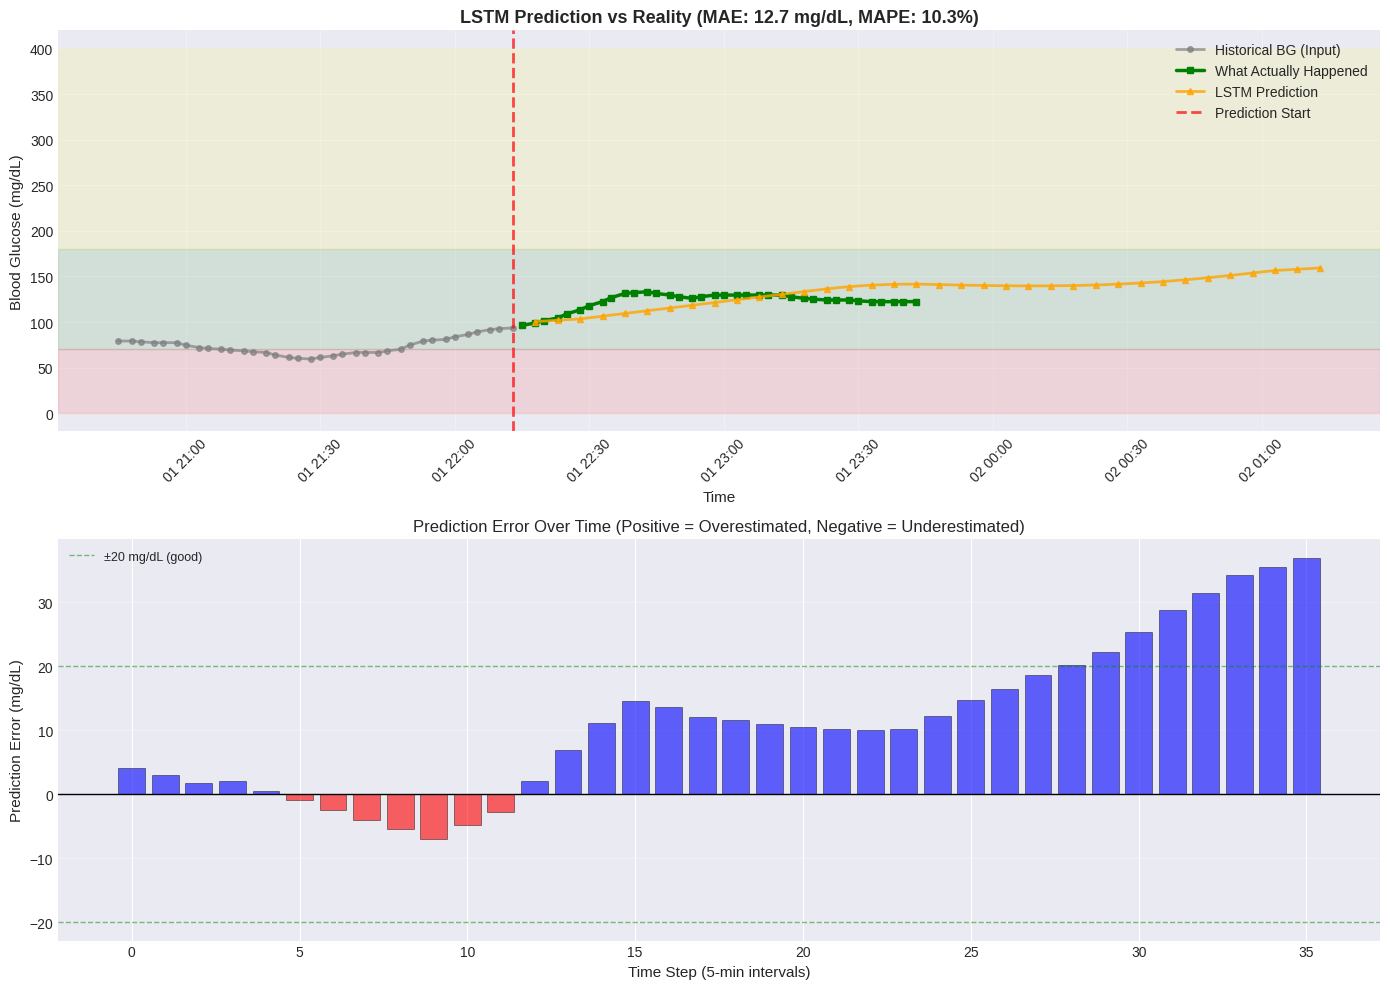


💡 Model Performance Interpretation:
✅ EXCELLENT: MAE < 15 mg/dL - Clinical-grade accuracy!
   Model predictions are highly reliable for decision making

✅ Clarke Grid: 100.0% in zones A+B (Excellent clinical safety)

📌 This is the REAL validation - comparing against actual patient outcomes!
   Much more meaningful than simglucose comparison.


In [14]:
# SCENARIO 1 BETTER VERIFICATION: Compare predictions with ACTUAL patient data
# This is the true test - did the model predict what really happened?

print("🔬 REAL VALIDATION: Comparing LSTM predictions vs actual patient outcomes\n")

# Get the actual glucose values that occurred in the next 3 hours
# We already have pred_values (36 steps = 3 hours) from the LSTM
# Now let's get what actually happened to this patient

# Calculate the indices for the actual future data
future_start_idx = end_idx  # Right after our history window
future_end_idx = future_start_idx + 36  # 3 hours ahead (36 * 5min = 180min)

# Check if we have enough data
if future_end_idx <= len(sample_person):
    # Extract actual future glucose values
    actual_future = sample_person.iloc[future_start_idx:future_end_idx]
    actual_bg_values = actual_future['bg'].tolist()
    actual_timestamps = actual_future['timestamp'].tolist()

    # Compare predictions with actual outcomes
    print("📊 Prediction vs Reality Comparison:")
    print(f"{'Time':<15} {'LSTM Predicted':<20} {'Actually Happened':<20} {'Error':<15}")
    print("-" * 70)

    # Key timepoints
    for idx, label in [(11, "+1 hour"), (23, "+2 hours"), (35, "+3 hours")]:
        if idx < len(pred_values) and idx < len(actual_bg_values):
            pred_val = pred_values[idx]
            actual_val = actual_bg_values[idx]
            error = pred_val - actual_val
            print(f"{label:<15} {pred_val:>8.1f} mg/dL      {actual_val:>8.1f} mg/dL      {error:>6.1f} mg/dL")

    # Calculate validation metrics
    min_len = min(len(pred_values), len(actual_bg_values))
    pred_array = np.array(pred_values[:min_len])
    actual_array = np.array(actual_bg_values[:min_len])

    mae_real = np.mean(np.abs(pred_array - actual_array))
    rmse_real = np.sqrt(np.mean((pred_array - actual_array)**2))
    mape = np.mean(np.abs((actual_array - pred_array) / actual_array)) * 100

    print(f"\n📈 Validation Metrics (LSTM vs Real Patient Data):")
    print(f"Mean Absolute Error (MAE):  {mae_real:.2f} mg/dL")
    print(f"Root Mean Square Error (RMSE): {rmse_real:.2f} mg/dL")
    print(f"Mean Absolute Percentage Error: {mape:.2f}%")

    # Clinical accuracy assessment
    # Clarke Error Grid zones
    def clarke_error_zone(actual, predicted):
        """Simplified Clarke Error Grid classification"""
        if actual < 70:
            if predicted < 70:
                return 'A'  # Both hypo - acceptable
            elif predicted < 180:
                return 'C'  # Missed hypo - dangerous
            else:
                return 'E'  # Critical error
        elif actual < 180:
            if 0.8 * actual <= predicted <= 1.2 * actual:
                return 'A'  # Within 20% - clinically accurate
            elif predicted < 70 or predicted > 180:
                return 'C'  # Wrong zone
            else:
                return 'B'  # Acceptable
        else:  # actual >= 180 (hyperglycemia)
            if predicted > 180:
                return 'B'  # Both high - acceptable
            elif predicted > 70:
                return 'C'  # Missed high
            else:
                return 'D'  # Dangerous

    # Calculate Clarke zones for all predictions
    zones = [clarke_error_zone(a, p) for a, p in zip(actual_array, pred_array)]
    zone_a_pct = (zones.count('A') / len(zones)) * 100
    zone_b_pct = (zones.count('B') / len(zones)) * 100

    print(f"\n🎯 Clinical Accuracy (Clarke Error Grid):")
    print(f"Zone A (Clinically Accurate): {zone_a_pct:.1f}%")
    print(f"Zone B (Acceptable):          {zone_b_pct:.1f}%")
    print(f"Zone A+B Combined:            {zone_a_pct + zone_b_pct:.1f}%")

    # Visualize the comparison
    plt.figure(figsize=(14, 8))

    # Create two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Top plot: Time series comparison
    ax1.plot(user_timestamps, user_bg, 'o-', label='Historical BG (Input)',
             color='gray', linewidth=2, alpha=0.7, markersize=4)
    ax1.plot(actual_timestamps[:min_len], actual_array, 's-',
             label='What Actually Happened', color='green', linewidth=2.5, markersize=5)
    ax1.plot(pred_times[:min_len], pred_array, '^-',
             label='LSTM Prediction', color='orange', linewidth=2, markersize=5, alpha=0.8)

    # Add vertical line separating history from prediction
    ax1.axvline(x=user_timestamps[-1], color='red', linestyle='--',
                linewidth=2, label='Prediction Start', alpha=0.7)

    # Safety zones
    ax1.axhspan(70, 180, alpha=0.1, color='green')
    ax1.axhspan(0, 70, alpha=0.1, color='red')
    ax1.axhspan(180, 400, alpha=0.1, color='yellow')

    ax1.set_xlabel('Time', fontsize=11)
    ax1.set_ylabel('Blood Glucose (mg/dL)', fontsize=11)
    ax1.set_title(f'LSTM Prediction vs Reality (MAE: {mae_real:.1f} mg/dL, MAPE: {mape:.1f}%)',
                  fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Bottom plot: Error over time
    errors = pred_array - actual_array
    ax2.bar(range(len(errors)), errors, color=['red' if e < 0 else 'blue' for e in errors],
            alpha=0.6, edgecolor='black', linewidth=0.5)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.axhline(y=20, color='green', linestyle='--', linewidth=1, alpha=0.5, label='±20 mg/dL (good)')
    ax2.axhline(y=-20, color='green', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Time Step (5-min intervals)', fontsize=11)
    ax2.set_ylabel('Prediction Error (mg/dL)', fontsize=11)
    ax2.set_title('Prediction Error Over Time (Positive = Overestimated, Negative = Underestimated)',
                  fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Interpretation
    print(f"\n💡 Model Performance Interpretation:")
    if mae_real < 15:
        print("✅ EXCELLENT: MAE < 15 mg/dL - Clinical-grade accuracy!")
        print("   Model predictions are highly reliable for decision making")
    elif mae_real < 25:
        print("✅ VERY GOOD: MAE < 25 mg/dL - Strong predictive performance")
        print("   Suitable for glucose trend prediction and alerts")
    elif mae_real < 35:
        print("✅ GOOD: MAE < 35 mg/dL - Acceptable for monitoring")
        print("   Useful for trend detection, but verify with CGM for critical decisions")
    elif mae_real < 50:
        print("⚠️  MODERATE: MAE < 50 mg/dL - Some utility but needs improvement")
        print("   Consider as a rough guide only, not for insulin dosing")
    else:
        print("⚠️  POOR: MAE >= 50 mg/dL - Limited clinical utility")
        print("   Model needs retraining with more data or better features")

    if zone_a_pct + zone_b_pct > 95:
        print(f"\n✅ Clarke Grid: {zone_a_pct + zone_b_pct:.1f}% in zones A+B (Excellent clinical safety)")
    elif zone_a_pct + zone_b_pct > 85:
        print(f"\n✅ Clarke Grid: {zone_a_pct + zone_b_pct:.1f}% in zones A+B (Good clinical safety)")
    else:
        print(f"\n⚠️  Clarke Grid: {zone_a_pct + zone_b_pct:.1f}% in zones A+B (Needs improvement)")

    print("\n📌 This is the REAL validation - comparing against actual patient outcomes!")
    print("   Much more meaningful than simglucose comparison.")

else:
    print(f"❌ Not enough future data available for validation")
    print(f"   Need data up to index {future_end_idx}, but only have {len(sample_person)} records")
    print("   Try selecting an earlier start_idx in the previous cell")

In [15]:
# SCENARIO 2: Pre-Meal Insulin Calculation
# User is about to eat, wants to know how much insulin to take

def calculate_insulin_recommendation(current_bg_readings, recent_insulin, recent_carbs,
                                     hr_data, steps_data, timestamps,
                                     planned_carbs, target_bg=120j,
                                     insulin_sensitivity=50, carb_ratio=10):
    """
    Recommend insulin dose for an upcoming meal and predict resulting glucose curve

    Parameters:
    -----------
    current_bg_readings : list of float
        Recent BG readings for context
    recent_insulin : list of float
        Recent insulin doses
    recent_carbs : list of float
        Recent carb intake
    hr_data, steps_data : list of float
        Activity data
    timestamps : list of datetime
        Timestamps for the readings
    planned_carbs : float
        Carbs user plans to eat (grams)
    target_bg : float
        Target blood glucose (mg/dL), default 120
    insulin_sensitivity : float
        How much 1 unit of insulin lowers BG (mg/dL), default 50
    carb_ratio : float
        Grams of carbs covered by 1 unit of insulin, default 10

    Returns:
    --------
    recommendation : dict with insulin dose and predicted glucose curve
    """

    current_bg = current_bg_readings[-1]

    # Calculate IOB (active insulin that's still working)
    metabolic_model = MetabolicModel(insulin_brand="Humalog")
    insulin_series = pd.Series(recent_insulin)
    iob_values = metabolic_model.calculate_iob(insulin_series)
    current_iob = iob_values[-1] if len(iob_values) > 0 else 0

    # Insulin dose calculation (simplified bolus calculator)
    # Correction dose: (current_bg - target_bg) / insulin_sensitivity
    correction_dose = max(0, (current_bg - target_bg) / insulin_sensitivity)

    # Carb coverage: planned_carbs / carb_ratio
    carb_coverage_dose = planned_carbs / carb_ratio

    # Account for IOB (don't stack insulin)
    iob_adjustment = current_iob * 0.5  # Conservative: only subtract 50% of IOB

    # Total recommended dose
    recommended_insulin = max(0, correction_dose + carb_coverage_dose - iob_adjustment)

    # Now predict what happens with this insulin dose
    # Create a modified history with the new insulin and carbs added
    modified_insulin = recent_insulin.copy()
    modified_carbs = recent_carbs.copy()

    # Add the new dose to the most recent timestep
    modified_insulin[-1] += recommended_insulin
    modified_carbs[-1] += planned_carbs

    # Make prediction
    predictions = predict_post_meal_glucose(
        current_bg_readings=current_bg_readings,
        insulin_doses=modified_insulin,
        carb_intakes=modified_carbs,
        hr_data=hr_data,
        steps_data=steps_data,
        timestamps=timestamps,
        hours_forward=3
    )

    return {
        'current_bg': current_bg,
        'current_iob': current_iob,
        'correction_dose': correction_dose,
        'carb_coverage_dose': carb_coverage_dose,
        'iob_adjustment': iob_adjustment,
        'recommended_insulin': recommended_insulin,
        'predictions': predictions
    }

print("✅ Pre-meal insulin calculation function defined")

✅ Pre-meal insulin calculation function defined


🍽️ User Scenario: About to eat dinner
Current BG: 250.2 mg/dL
Planned meal: 60g carbs

💉 Calculating insulin recommendation...
Model initialized for Humalog (Peak: ~60 min)
Model initialized for Humalog (Peak: ~60 min)

📊 Insulin Dose Breakdown:
├─ Current BG: 250.2 mg/dL
├─ Active Insulin (IOB): 0.09 units
├─ Correction dose: 2.60 units
├─ Carb coverage: 6.00 units
└─ IOB adjustment: -0.04 units

💉 RECOMMENDED INSULIN: 8.6 units
Model initialized for Humalog (Peak: ~60 min)


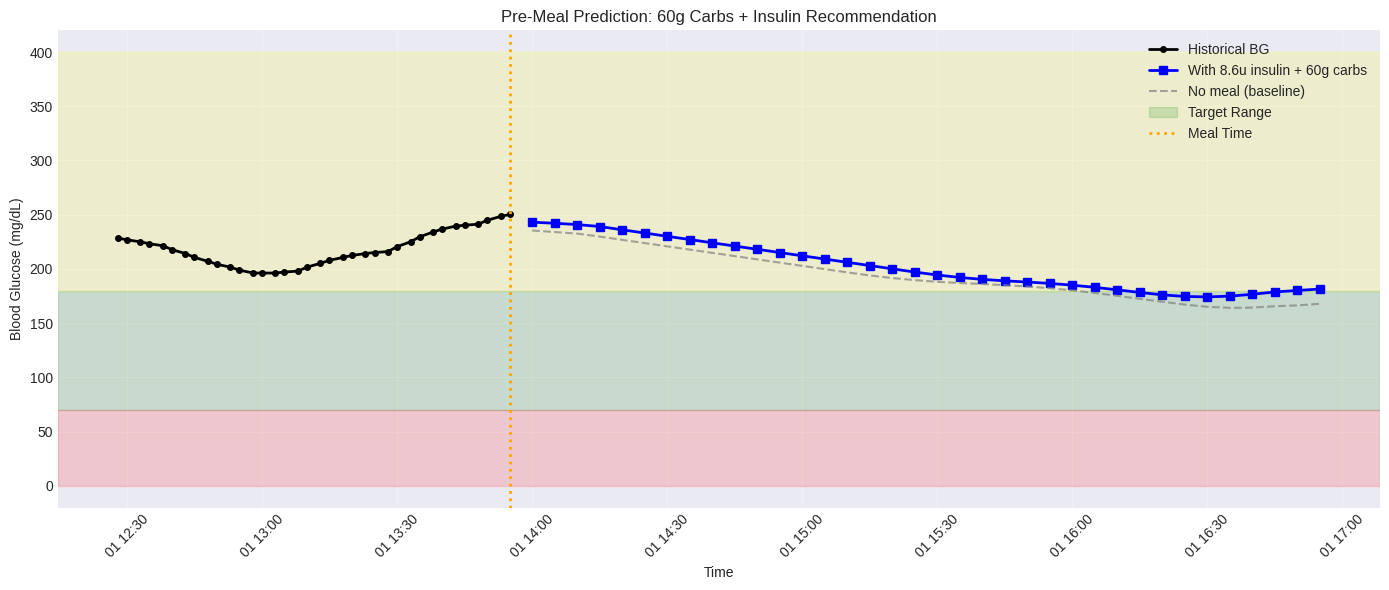


📈 Predicted Glucose Response:
├─ Peak BG: 243.1 mg/dL
├─ Time to peak: 5 minutes after meal
├─ BG at 1h: 215.1 mg/dL
├─ BG at 2h: 186.6 mg/dL
└─ BG at 3h: 181.4 mg/dL

⚠️ WARNING: Peak glucose may exceed target
   Consider increasing insulin by 0.5-1.0 units


In [16]:
# SCENARIO 2 EXAMPLE: User is about to eat dinner, needs insulin recommendation

# Use recent data as context
sample_person = df_p03  # You can change to df, df17, etc.

# Pick a time point (e.g., just before a meal)
start_idx = 300
end_idx = start_idx + LOOK_BACK

recent_history = sample_person.iloc[start_idx:end_idx]

# Extract history
user_bg = recent_history['bg'].tolist()
user_insulin = recent_history['insulin'].tolist()
user_carbs = recent_history['carbs'].tolist()
user_hr = recent_history['hr'].tolist()
user_steps = recent_history['steps'].tolist()
user_timestamps = recent_history['timestamp'].tolist()

# USER INPUT: Meal planning
PLANNED_CARBS = 60  # User plans to eat 60g carbs (e.g., pasta meal)

print("🍽️ User Scenario: About to eat dinner")
print(f"Current BG: {user_bg[-1]:.1f} mg/dL")
print(f"Planned meal: {PLANNED_CARBS}g carbs")
print(f"\n💉 Calculating insulin recommendation...")

try:
    # Calculate recommendation
    result = calculate_insulin_recommendation(
        current_bg_readings=user_bg,
        recent_insulin=user_insulin,
        recent_carbs=user_carbs,
        hr_data=user_hr,
        steps_data=user_steps,
        timestamps=user_timestamps,
        planned_carbs=PLANNED_CARBS,
        target_bg=120,
        insulin_sensitivity=50,  # Adjust based on individual
        carb_ratio=10  # Adjust based on individual
    )

    # Display recommendation
    print(f"\n📊 Insulin Dose Breakdown:")
    print(f"├─ Current BG: {result['current_bg']:.1f} mg/dL")
    print(f"├─ Active Insulin (IOB): {result['current_iob']:.2f} units")
    print(f"├─ Correction dose: {result['correction_dose']:.2f} units")
    print(f"├─ Carb coverage: {result['carb_coverage_dose']:.2f} units")
    print(f"└─ IOB adjustment: -{result['iob_adjustment']:.2f} units")
    print(f"\n💉 RECOMMENDED INSULIN: {result['recommended_insulin']:.1f} units")

    # Extract predictions
    predictions = result['predictions']
    pred_times = [p[0] for p in predictions]
    pred_values = [p[1] for p in predictions]

    # Create comparison: with vs without recommended insulin
    # Predict without the meal/insulin (baseline)
    baseline_predictions = predict_post_meal_glucose(
        current_bg_readings=user_bg,
        insulin_doses=user_insulin,
        carb_intakes=user_carbs,
        hr_data=user_hr,
        steps_data=user_steps,
        timestamps=user_timestamps,
        hours_forward=3
    )
    baseline_values = [p[1] for p in baseline_predictions]

    # Plot the predictions
    plt.figure(figsize=(14, 6))

    # Historical data
    plt.plot(user_timestamps, user_bg, 'o-', label='Historical BG',
             color='black', linewidth=2, markersize=4)

    # Predicted with insulin
    plt.plot(pred_times, pred_values, 's-',
             label=f'With {result["recommended_insulin"]:.1f}u insulin + {PLANNED_CARBS}g carbs',
             color='blue', linewidth=2)

    # Baseline (no meal)
    plt.plot(pred_times, baseline_values, '--',
             label='No meal (baseline)',
             color='gray', linewidth=1.5, alpha=0.7)

    # Safety zones
    plt.axhspan(70, 180, alpha=0.15, color='green', label='Target Range')
    plt.axhspan(0, 70, alpha=0.15, color='red')
    plt.axhspan(180, 400, alpha=0.15, color='yellow')

    # Mark the meal time
    meal_time = user_timestamps[-1]
    plt.axvline(x=meal_time, color='orange', linestyle=':', linewidth=2, label='Meal Time')

    plt.xlabel('Time')
    plt.ylabel('Blood Glucose (mg/dL)')
    plt.title(f'Pre-Meal Prediction: {PLANNED_CARBS}g Carbs + Insulin Recommendation')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Time to peak and safety analysis
    peak_bg = max(pred_values)
    peak_time_idx = pred_values.index(peak_bg)
    peak_time = pred_times[peak_time_idx]
    time_to_peak = (peak_time - meal_time).total_seconds() / 60  # minutes

    print(f"\n📈 Predicted Glucose Response:")
    print(f"├─ Peak BG: {peak_bg:.1f} mg/dL")
    print(f"├─ Time to peak: {time_to_peak:.0f} minutes after meal")
    print(f"├─ BG at 1h: {pred_values[11]:.1f} mg/dL")
    print(f"├─ BG at 2h: {pred_values[23]:.1f} mg/dL")
    print(f"└─ BG at 3h: {pred_values[35]:.1f} mg/dL")

    # Safety alerts
    if peak_bg > 180:
        print(f"\n⚠️ WARNING: Peak glucose may exceed target")
        print(f"   Consider increasing insulin by 0.5-1.0 units")
    elif min(pred_values) < 70:
        print(f"\n⚠️ WARNING: Risk of hypoglycemia")
        print(f"   Consider reducing insulin by 0.5-1.0 units")
    else:
        print(f"\n✅ Predicted glucose response within target range")

except Exception as e:
    print(f"Error: {e}")

In [18]:
import os
import pickle

# Define the directory to save the model and scaler
backend_dir = './models'
os.makedirs(backend_dir, exist_ok=True) # Create the directory if it doesn't exist

# Save the trained model
model.save(os.path.join(backend_dir, 'lstm_model.h5'))
print(f"✓ Model saved to {backend_dir}/lstm_model.h5")

# Save the scaler
with open(os.path.join(backend_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to {backend_dir}/scaler.pkl")

✓ Model saved to ./models/lstm_model.h5
✓ Scaler saved to ./models/scaler.pkl
